# Sivers: azimuthal-acceptance comparison

The SoLID 3He (neutron) Sivers fit across **four** pseudodata configurations, all
generated in this repo and all fitted at 500 replicas, against the world-data fit
as the reference. The Sivers counterpart of `plot-transversity_phicompare.ipynb`;
the physics machinery (`f1tcalcorr`, `tmd.f1Tperp1`, the
$xf_{1T}^{\perp(1)}$ observable) is unchanged.

| key | run directory | acceptance | binning | bins |
|---|---|---|---|---|
| `world` | `../data_world` | existing world data — **the reference** | — | 234 rows |
| `sbs` | `../data_world` | SBS projection — a second external reference, **stat-only panel** | — | 455 rows |
| `phifull` | `data_phifull` | full 2π (100%) | own | 1660 |
| `phi4seg_fullbin` | `data_phi4seg24deg_phifullbin` | 4 × 24° (26.7% nominal), both arms | **reused from `phifull`** | 1660 |
| `phi4segFA_fullbin` | `data_phi4seg24degFA_phifullbin` | 4 × 24°, **forward angle only** (large-angle e⁻ keeps full 2π) | **reused from `phifull`** | 1660 |
| `phi4segFA` | `data_phi4seg24degFA` | 4 × 24°, forward angle only | own | 239 |

The `*_fullbin` runs share `phifull`'s bins, so they pair 1:1 with it and with
each other — those are the ones to compare. The own-bins runs re-binned under
their own acceptance, trading fewer bins for more events in each, which makes
them look better at equal acceptance for reasons of bin width rather than physics.

**The nominal coverage is not the event cost.** The cut applies to the electron
and the hadron alike, so a coincidence survives roughly 26.7² ≈ 7.1%; measured,
the median surviving yield is 4.8%. See `README.md` in this directory.

*(Rewritten 2026-08-31: the previous version read `output*` directories and
`tmdlib.tmd` from the upstream tree, and covered 6×24° and 4×12°FA
configurations that do not exist here.)*

**SBS is a reference, not a SoLID configuration.** It is an external projection with no systematics model of its own, so there is a single SBS fit rather than a stat/syst pair, and it is drawn in the **stat-only panel only** — absent from every stat+syst panel and table rather than repeated there unchanged. Fitted at 500 replicas like everything else, so its 3.2% replica-sampling noise is the same as the rest.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

GALLERY = 'gallery'
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4    # the single Q2 the ratio tables use
# The band figures draw every entry: the first carries the error band, any others
# would be central curves showing the Q2 evolution.
# One Q2. The machinery below still loops, so adding values back is a
# one-line change; with a single entry the band is drawn and nothing else.
Q2LIST = [2.4]
tol = 1.5    # Sivers value (the transversity notebook uses 7.04); it cancels in
             # every error RATIO below, so the comparisons do not depend on it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,au,bu,cu,Nd,ad,bd,cd,Nub,Ndb,kt2,chi2`).

In [2]:
STAT, SYST = 'out-enhanced3he_sivers.dat', 'out-enhanced3hesyst_sivers.dat'

# REF is the denominator of every error ratio below.
# The 4x-counts twins, derived from STAT/SYST rather than spelled out, so a change
# to the amplitude or the file naming carries through to both. They come from the
# fit scripts' -c 4 flag: the SoLID statistical error divided by sqrt(4), with the
# systematic budget left alone. For the *syst files the total error is REBUILT as
# sqrt(stat^2/4 + systabs^2 + AUT^2 systrel^2) rather than scaled whole -- more
# beam time does not shrink a systematic, and scaling error_tot would claim it does.
STAT_X4, SYST_X4 = (v.replace('.dat', '_x4counts.dat') for v in (STAT, SYST))

REF = 'world'

# Four curves and the world reference. The question here is narrow: what does the
# 4x24 deg phi cut cost at FOUR TIMES the counts -- on both arms, and on the
# forward angle only -- against the full-2pi run at its
# nominal luminosity, with SBS as the external yardstick.
#
# Deliberately absent, and where they live instead:
#   the R1 < 0.3 cut          -> a different question entirely
#   the 1x twins of the phi-cut runs, the own-bins 4x24 deg run (169 bins),
#   and the 806-bin count binning
#                             -> plot-*_phicompare_x4counts.ipynb pairs 1x with 4x
#                                across four configurations; the binning scan is in
#                                plot-*_phicompare_morebin.ipynb
#
# 2pi and SBS stay at 1x on purpose. 2pi is the reference the phi cut is measured
# against, not a configuration whose luminosity is in question, and --counts never
# scales SBS at all: more SoLID beam time does not give SBS more events.
RUNS = {
    'world':             {'dir': '../data_world',
                          # the world fit has no stat/syst variants -- the same
                          # fit is the reference in both panels
                          'files': {'': 'out-world_sivers.dat', 'syst': 'out-world_sivers.dat'},
                          'label': r'$\rm world~data$',
                          'color': 'gray'},
    # one fit, no stat/syst split: no 'syst' key, so runs_for() leaves SBS out of
    # every stat+syst panel.
    'sbs':               {'dir': '../data_sbs',
                          'files': {'': 'out-sbs_sivers.dat'},
                          'label': r'$\rm SBS$',
                          'color': 'saddlebrown'},
    'phifull':           {'dir': 'data_phifull',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm SoLID~full~2\pi$',
                          'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT_X4, 'syst': SYST_X4},
                          'label': r'$\rm 4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                          'color': 'green'},
    # the same 4x24 deg cut applied at forward angle only: a large-angle electron
    # keeps full 2pi. Same 1660 bins as phifull and phi4seg_fullbin_x4, so the
    # three compare bin for bin.
    'phi4segFA_fullbin_x4': {'dir': 'data_phi4seg24degFA_phifullbin',
                          'files': {'': STAT_X4, 'syst': SYST_X4},
                          'label': r'$\rm 4\times24^\circ~FA~(2\pi~bins,~4\times~counts)$',
                          'color': 'purple'},
}
# 'sbs' is an external projection with no systematics model of its own: there is
# one SBS fit, not a stat/syst pair, so it belongs in the stat-only panel and
# nowhere else. The mechanism is the absence of a 'syst' entry in its `files` --
# every loop below iterates runs_for(suffix), so each run appears in exactly the
# panels it has a fit for. 'world' is the reference (the denominator of every
# ratio) and so carries both, pointing at the same file twice.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['', 'syst']

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:24s} {"-- no fit; absent from this panel":52s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:24s} {path:56s} {len(par[run+suf])} replicas')


world                    ../data_world/out-world_sivers.dat                       500 replicas
worldsyst                ../data_world/out-world_sivers.dat                       500 replicas
sbs                      ../data_sbs/out-sbs_sivers.dat                           500 replicas
sbssyst                  -- no fit; absent from this panel                   
phifull                  data_phifull/out-enhanced3he_sivers.dat                  500 replicas
phifullsyst              data_phifull/out-enhanced3hesyst_sivers.dat              500 replicas
phi4seg_fullbin_x4       data_phi4seg24deg_phifullbin/out-enhanced3he_sivers_x4counts.dat 500 replicas


phi4seg_fullbin_x4syst   data_phi4seg24deg_phifullbin/out-enhanced3hesyst_sivers_x4counts.dat 500 replicas
phi4segFA_fullbin_x4     data_phi4seg24degFA_phifullbin/out-enhanced3he_sivers_x4counts.dat 500 replicas
phi4segFA_fullbin_x4syst data_phi4seg24degFA_phifullbin/out-enhanced3hesyst_sivers_x4counts.dat 500 replicas


### Fitted parameters, run by run

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
pd.set_option('display.width', 250)
partable = pd.DataFrame(rows).set_index('run')
partable[['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2', 'chi2']]

,Nu,au,bu,Nd,ad,bd,kt2,chi2
run,,,,,,,,
world,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
worldsyst,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
sbs,-0.0357 +- 0.0081,0.6078 +- 0.0642,4.2252 +- 1.0423,0.0470 +- 0.0088,0.3318 +- 0.0861,3.4107 +- 0.7871,0.1591 +- 0.0150,449.2308 +- 30.6505
phifull,-0.0374 +- 0.0064,0.6315 +- 0.0472,4.1441 +- 0.8068,0.0499 +- 0.0051,0.3714 +- 0.0485,3.3170 +- 0.5645,0.1600 +- 0.0016,1650.3382 +- 56.9493
phifullsyst,-0.0373 +- 0.0066,0.6277 +- 0.0475,4.1453 +- 0.8341,0.0497 +- 0.0057,0.3633 +- 0.0589,3.3128 +- 0.6192,0.1600 +- 0.0038,1650.6999 +- 56.9243
phi4seg_fullbin_x4,-0.0361 +- 0.0085,0.6087 +- 0.0756,4.2501 +- 1.0429,0.0489 +- 0.0064,0.3563 +- 0.0677,3.4047 +- 0.7111,0.1602 +- 0.0034,1651.1967 +- 56.8811
phi4seg_fullbin_x4syst,-0.0360 +- 0.0085,0.6075 +- 0.0764,4.2584 +- 1.0382,0.0489 +- 0.0068,0.3540 +- 0.0676,3.3818 +- 0.7655,0.1602 +- 0.0052,1651.4236 +- 56.8739
phi4segFA_fullbin_x4,-0.0365 +- 0.0076,0.6155 +- 0.0683,4.1965 +- 0.8923,0.0490 +- 0.0058,0.3585 +- 0.0636,3.3814 +- 0.6327,0.1602 +- 0.0034,1650.9649 +- 56.9105
phi4segFA_fullbin_x4syst,-0.0364 +- 0.0076,0.6150 +- 0.0668,4.1997 +- 0.8971,0.0489 +- 0.0060,0.3563 +- 0.0637,3.3760 +- 0.6655,0.1602 +- 0.0051,1651.1828 +- 56.9094


## Calculate $xf_{1T}^{\perp(1)}(x)$

Follows `f1tcalc()` in `plot-sivers.ipynb`: for each $x$, evaluate
`tmd.f1Tperp1` once per replica using that replica's own parameters, take the
valence combination $q - \bar q$, then central value = mean, error = `tol` × std.

(`Nub`/`Ndb` are fixed to 0 in `fitsim`, so the $\bar q$ terms vanish — the
subtraction is kept for fidelity with the reference notebook.)

In [4]:
def f1tcalcorr(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        # errors only -- central values are untouched. Identically 1 for x <= 0.4,
        # exp(-6.8*(x-0.4)^2) above: x0.76 at x=0.6, x0.34 at x=0.8, x0.09 at x=1.
        corr = np.exp(-1.7 * (np.abs(x - 0.4) + x - 0.4)**2)
        xu, xd = [], []
        for i in range(len(pset)):
            f1t = tmd.f1Tperp1(x, Q2, 'proton', pset.loc[i])
            xu.append(x * (f1t[2] - f1t[-2]))
            xd.append(x * (f1t[1] - f1t[-1]))
        rows.append({'x': x,
                     'xu': np.mean(xu), 'Exu': tol * np.std(xu) * corr,
                     'xd': np.mean(xd), 'Exd': tol * np.std(xd) * corr})
    return pd.DataFrame(rows)

In [5]:
%%time
f1t = {}
for q2 in Q2LIST:
    f1t[q2] = {}
    for key in par:
        f1t[q2][key] = f1tcalcorr(par[key], q2, tol)
    print('done Q2 =', q2)

done Q2 = 2.4
CPU times: user 1min 52s, sys: 63.4 ms, total: 1min 52s
Wall time: 1min 53s


## $xf_{1T}^{\perp(1)}(x)$ bands, three runs overlaid

Top panel: $u$ (solid) and $d$ (dashed) Sivers first-moment bands. Bottom panel:
each φ-cut run's uncertainty relative to the full-2π baseline — above 1 means
the φ cut degrades the projection. `tol` cancels in the bottom panel.

In [6]:
def band_plot(suffix, fname, title):
    fig = plt.figure(figsize=(6.5, 10))

    ax = fig.add_subplot(2, 1, 1)
    # Q2 is shown by WEIGHT, not by linestyle: solid/dashed already carries u/d, so
    # the extra Q2 curves are the same colour drawn lighter and thinner. Bands are
    # drawn only at the first Q2 -- one band per run per Q2 would be 15 overlapping
    # fills. The error RATIO in the lower panel is Q2-independent by construction
    # (the fitted parameters enter the distribution only as a factor multiplying the
    # shared unpolarised PDF), so nothing is lost by leaving that panel at one Q2.
    for k, q2 in enumerate(Q2LIST):
        first = (k == 0)
        lw, al = (1.2, 1.0) if first else (0.9, 0.50 - 0.15 * k)
        for run, cfg in runs_for(suffix):
            d = f1t[q2][run + suffix]
            if first:
                ax.fill_between(d['x'], d['xu'] - d['Exu'], d['xu'] + d['Exu'],
                                color=cfg['color'], alpha=0.30, linewidth=0)
                ax.fill_between(d['x'], d['xd'] - d['Exd'], d['xd'] + d['Exd'],
                                color=cfg['color'], alpha=0.30, linewidth=0)
            ax.plot(d['x'], d['xu'], color=cfg['color'], linewidth=lw, alpha=al,
                    label=cfg['label'] if first else None)
            ax.plot(d['x'], d['xd'], color=cfg['color'], linewidth=lw, alpha=al,
                    linestyle='--')
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xf_{1T}^{\perp(1)}(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.042, 0.05)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=17)
    ax.text(0.03, 0.90, r'$Q^2 = $' + r',~'.join(f'{q:g}' for q in Q2LIST)
            + r'$~{\rm GeV}^2$' + ('' if len(Q2LIST) == 1 else ', heavy to light'),
            transform=ax.transAxes, fontsize=13)
    # u and d labelled ON the curves, placed by the SIGN of each lobe so the reader
    # never has to work out which is which. The world fit is used for the position
    # because it is present in every panel.
    dref = f1t[Q2LIST[0]][REF + suffix]
    j = int(np.argmin(np.abs(dref['x'].values - 0.25)))
    lo, hi = ax.get_ylim()
    pad = 0.045 * (hi - lo)
    for q, lab in (('xu', 'u'), ('xd', 'd')):
        v = dref[q].values[j]
        ax.text(0.25, v + (pad if v >= 0 else -pad), rf'${lab}$', fontsize=19,
                ha='center', va='bottom' if v >= 0 else 'top', color='black')
    ax.legend(loc='lower right', frameon=False, fontsize=13)

    ax = fig.add_subplot(2, 1, 2)
    # The same three Q2 as the upper panel, same weight convention. THEY LAND
    # EXACTLY ON TOP OF EACH OTHER, and that is the point worth seeing: the fitted
    # parameters enter the distribution only as a factor multiplying the shared
    # unpolarised PDF, so the PDF's Q2 evolution is common to every replica and
    # cancels identically in a ratio of errors. Checked directly -- world/phifull
    # for xh1_u at x = 0.25 is 8.3633643878 at Q2 = 2.4, 5.0 and 7.5 alike. Three
    # coincident curves is the visual statement that this model carries no fitted
    # Q2 dependence for the binning to resolve.
    for k, q2 in enumerate(Q2LIST):
        first = (k == 0)
        lw, al = (3.0, 0.8) if first else (2.0 - 0.5 * k, 0.5 - 0.12 * k)
        ref = f1t[q2][REF + suffix]
        for run, cfg in runs_for(suffix):
            if run == REF:
                continue
            d = f1t[q2][run + suffix]
            ax.plot(d['x'], ref['Exu'] / d['Exu'], color=cfg['color'], alpha=al,
                    linestyle='-',  linewidth=lw,
                    label=(cfg['label'] + r'$~u$') if first else None)
            ax.plot(d['x'], ref['Exd'] / d['Exd'], color=cfg['color'], alpha=al,
                    linestyle='--', linewidth=lw,
                    label=(cfg['label'] + r'$~d$') if first else None)
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for y in (10, 20, 30, 40):
        ax.axhline(y=y, linestyle=':', color='black', alpha=0.5, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{world}/Error$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 60)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

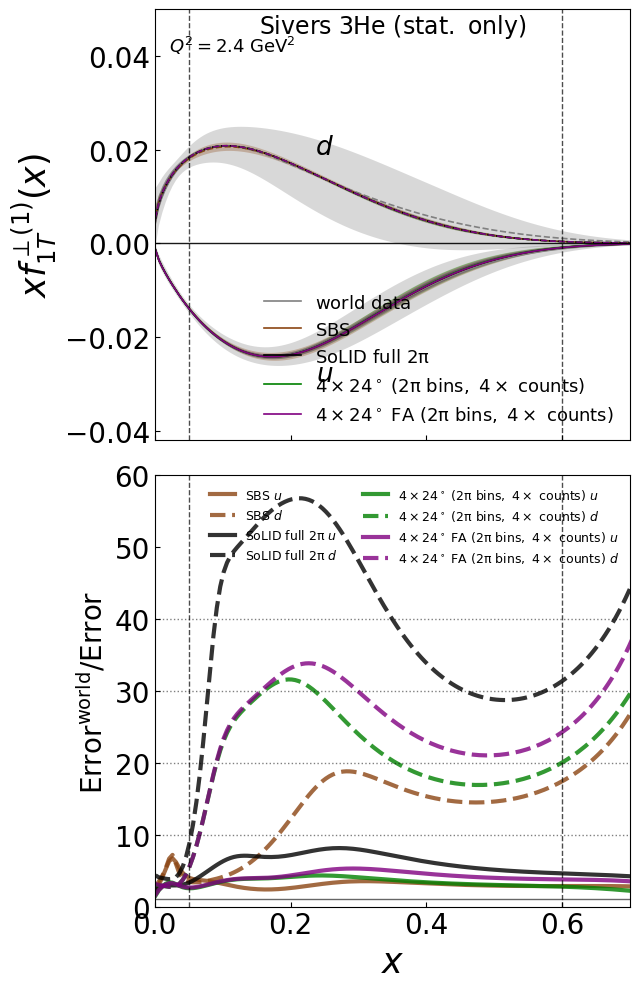

In [7]:
band_plot('', 'sivers-phicompare.pdf',
          r'$\rm Sivers~3He~(stat.~only)$');

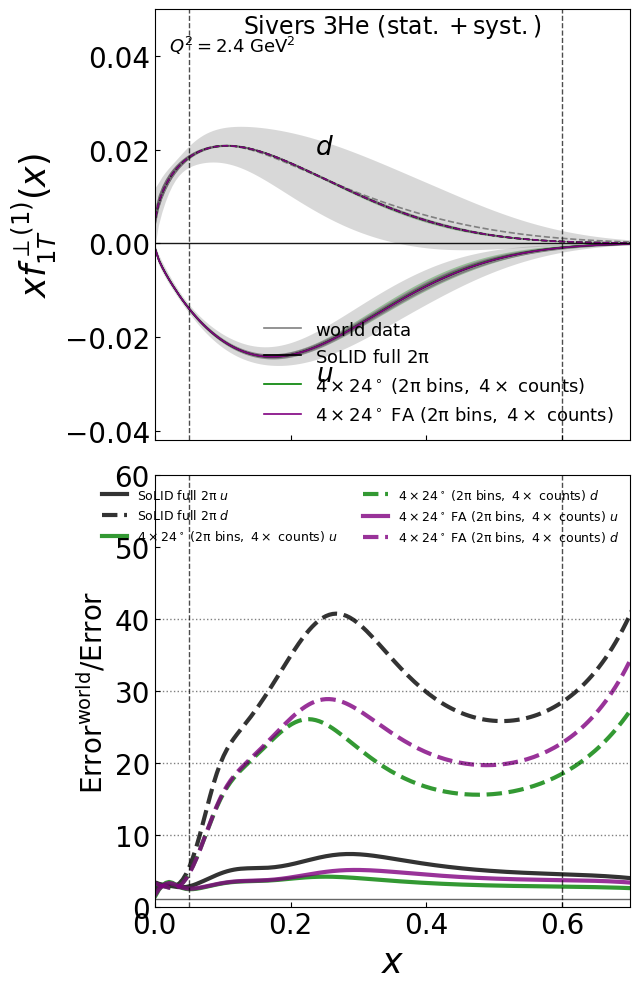

In [8]:
band_plot('syst', 'sivers-phicompare-syst.pdf',
          r'$\rm Sivers~3He~(stat.+syst.)$');

## Uncertainty ratio at representative $x$

Same information as the bottom panels, tabulated across the SoLID coverage.

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = f1t[Q2LIST[0]][REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[Q2LIST[0]][run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  x=0.6
variant   run                  quark                                                  
stat      sbs                  u        3.98   3.15   2.60   3.53   3.24   2.92   2.86
                               d        3.42   4.17  12.43  18.58  15.41  14.60  17.35
          phifull              u        3.37   6.35   7.19   7.93   6.28   5.14   4.63
                               d        8.89  46.54  56.69  47.77  34.14  28.86  31.28
          phi4seg_fullbin_x4   u        2.55   3.53   4.15   4.05   3.39   3.02   2.78
                               d        5.60  23.08  31.60  23.79  18.17  17.01  19.96
          phi4segFA_fullbin_x4 u        2.64   3.60   4.36   5.28   4.59   4.00   3.79
                               d        5.58  23.40  33.28  29.73  23.12  21.06  24.18
stat+syst phifull              u        2.83   4.76   5.89   7.27   5.96   4.95   4.51
                               d        5.59  20.98  35.17  39.21  30.04  25.87  28.35
          phi4seg_fullbin_x4   u        2.41   3.25   3.90   3.94   3.30   2.94   2.78
                               d        4.74  15.80  25.40  21.86  16.73  15.65  18.40
          phi4segFA_fullbin_x4 u        2.49   3.31   4.08   5.09   4.47   3.91   3.68
                               d        4.68  16.00  26.32  27.21  21.57  19.70  22.68

## Parameter-level summary

The Sivers fit has no tensor-charge analogue of $g_T$, so the compact summary is
the replica spread of the fitted parameters themselves. `kt2` is the one to
watch: it sets the transverse-momentum width, which is what an azimuthal
acceptance cut degrades most directly.

**Do not read the "vs world" parameter column as a precision comparison.**
`fitworld()` and `fitsim()` fix *different* parameters: the world fit floats 7
(`fix=[F,F,F,T,F,F,F,T,T,T,F]` — `cu`, `cd`, `Nub`, `Ndb` held), while the SoLID
fits float 9 (only `Nub`, `Ndb` held). Letting `cu`/`cd` float gives the SoLID
replicas extra freedom that inflates individual parameter spreads, which is why
`Nu` comes out with a *larger* std than world's despite SoLID being far more
precise on the actual observable. The band ratios above (which marginalise over
the whole parameter set) are the meaningful comparison against world; the
run-to-run column below, which compares like-configured `fitsim` outputs to each
other, is the meaningful one for the φ-cut effect.

In [10]:
COLS = ['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2']

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: std(world)/std, larger = better '
          f'(NOT a precision comparison -- different params fixed, see above) ---')
    ref = par[REF + suffix]
    for run, cfg in runs_for(suffix):
        cells = [f'{c}={ref[c].std()/par[run+suffix][c].std():.2f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: replica-std ratio to SoLID full-2pi '
          f'(like-for-like -- this is the phi-cut effect) ---')
    ref = par['phifull' + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        cells = [f'{c}={par[run+suffix][c].std()/ref[c].std():.3f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

print('--- systematics penalty: std(stat+syst) / std(stat) ---')
for run, cfg in runs_for('syst'):
    if run == REF:
        continue          # world has no syst variant; SBS is already excluded
    cells = [f'{c}={par[run+"syst"][c].std()/par[run][c].std():.2f}' for c in COLS]
    print(f'  {run:18s} ' + '  '.join(cells))
print()
print('Ratios marginally below 1.0 are 500-replica sampling noise (3.2%), not a')
print('real reduction -- adding systematics cannot shrink an error. Use them as')
print('the scale for how much of the near-1.0 numbers above is meaningful.')

--- stat: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world              Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  sbs                Nu=0.23  au=1.76  bu=1.00  Nd=1.76  ad=2.91  bd=4.03  kt2=2.00
  phifull            Nu=0.29  au=2.39  bu=1.29  Nd=3.00  ad=5.17  bd=5.62  kt2=18.58
  phi4seg_fullbin_x4 Nu=0.22  au=1.49  bu=1.00  Nd=2.43  ad=3.70  bd=4.46  kt2=8.79
  phi4segFA_fullbin_x4 Nu=0.25  au=1.66  bu=1.17  Nd=2.68  ad=3.94  bd=5.01  kt2=8.84

--- stat+syst: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world              Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  phifull            Nu=0.28  au=2.38  bu=1.25  Nd=2.71  ad=4.25  bd=5.12  kt2=7.80
  phi4seg_fullbin_x4 Nu=0.22  au=1.48  bu=1.01  Nd=2.27  ad=3.70  bd=4.14  kt2=5.82
  phi4segFA_fullbin_x4 Nu=0.25  au=1.69  bu=1.16  Nd=2.56  ad=3.93  bd=4.76  kt2=5.86

--- stat